In [1]:
import urllib.request
import json

import paths
import importlib
import xarray as xr
import os

from tqdm import tqdm
from download_data import nrfa_api, download_shapefiles

importlib.reload(paths)
importlib.reload(nrfa_api)
importlib.reload(download_shapefiles)

<module 'download_data.download_shapefiles' from '/Users/av656/Documents/Cambridge/PhD Research/Coding/Lowlands-vs_highlands-streamflow/download_data/download_shapefiles.py'>

In [11]:
full_pressure_data = xr.open_mfdataset(paths.WEATHER_UK + '/Pressure/Pressure_*.nc', concat_dim='valid_time', combine='nested', engine='netcdf4')

In [14]:
xr.open_dataset(paths.RAINFALL_UK)

<xarray.Dataset> Size: 13GB
Dimensions:     (time: 43, valid_time: 15706, latitude: 49, longitude: 49)
Coordinates:
  * latitude    (latitude) float64 392B 60.0 59.75 59.5 ... 48.5 48.25 48.0
  * longitude   (longitude) float64 392B -8.0 -7.75 -7.5 -7.25 ... 3.5 3.75 4.0
  * valid_time  (valid_time) datetime64[ns] 126kB 1979-01-01 ... 2021-12-31
    number      int64 8B ...
Dimensions without coordinates: time
Data variables:
    tp          (time, valid_time, latitude, longitude) float32 6GB ...
    smlt        (time, valid_time, latitude, longitude) float32 6GB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-06-23T14:34 GRIB to CDM+CF via cfgrib-0.9.1...

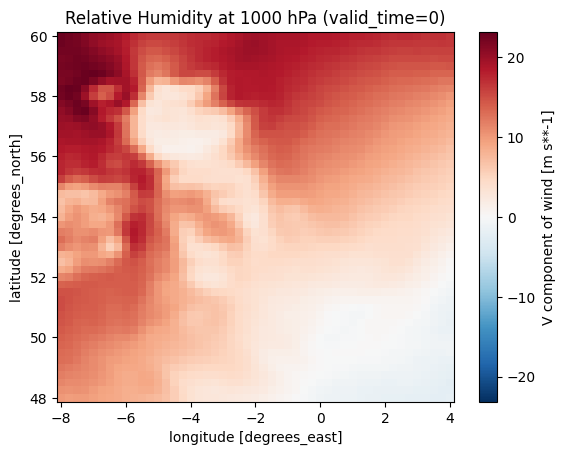

In [13]:
import xarray as xr
import matplotlib.pyplot as plt

# Open the file
ds = xr.open_dataset(paths.DATA + '/weather_UK/Pressure/Pressure_20071000hPa.nc')
ds = full_pressure_data 

# Choose a time slice and squeeze singleton dims
r = ds['v'].sel(pressure_level=1000).isel(valid_time=50).squeeze()

# Plot as 2D map
r.plot()
plt.title("Relative Humidity at 1000 hPa (valid_time=0)")
plt.show()

In [46]:
print(v.values)
print(f"Min: {r.min().values}, Max: {r.max().values}")


NameError: name 'v' is not defined

In [52]:
# Should return a number if data exists
domain_weather['v'].sel(pressure_level=1000).isel(valid_time=0, time=1, latitude=0, longitude=0).values


array(nan, dtype=float32)

In [ ]:
# Should return a number if data exists
domain_data['v'].sel(pressure_level=1000).isel(valid_time=0, latitude=0, longitude=0).values


In [112]:
import csv

# === UTILS ===
def load_processed_stations(log_path):
    if not os.path.exists(log_path):
        return set()
    with open(log_path, newline="") as csvfile:
        reader = csv.DictReader(csvfile)
        return set(row['station_id'] for row in reader)

In [120]:
import json

QUALIFYING_IDS_PATH = paths.DATA + "/qualifying_station_ids.json"
LOG_IDS_PATH = paths.DATA + "/station_download_log.json"

with open(LOG_IDS_PATH, "r") as f:
    qualifying_ids = json.load(f)
    
print(qualifying_ids)

{'2001': {'flow_success': True, 'shape_success': True, 'status': 'success'}, '3002': {'flow_success': True, 'shape_success': True, 'status': 'success'}, '3003': {'flow_success': True, 'shape_success': True, 'status': 'success'}, '3004': {'flow_success': True, 'shape_success': True, 'status': 'success'}, '4001': {'flow_success': True, 'shape_success': True, 'status': 'success'}, '4003': {'flow_success': True, 'shape_success': True, 'status': 'success'}, '6007': {'flow_success': True, 'shape_success': True, 'status': 'success'}, '6008': {'flow_success': True, 'shape_success': True, 'status': 'success'}, '7001': {'flow_success': True, 'shape_success': True, 'status': 'success'}, '7002': {'flow_success': True, 'shape_success': True, 'status': 'success'}, '7003': {'flow_success': True, 'shape_success': True, 'status': 'success'}, '7004': {'flow_success': True, 'shape_success': True, 'status': 'success'}, '7005': {'flow_success': True, 'shape_success': True, 'status': 'success'}, '8002': {'f

In [15]:
# 🔁 Example usage
download_shapefiles.download_shapefile_auto(3003)


🚀 Opening station 3003 download page...
ℹ️ No cookie popup found.
❌ Failed to set sector via native JS: Message: no such window: target window already closed
from unknown error: web view not found
  (Session info: chrome=138.0.7204.101)
Stacktrace:
0   chromedriver                        0x0000000102cd8e6c cxxbridge1$str$ptr + 2722840
1   chromedriver                        0x0000000102cd0d74 cxxbridge1$str$ptr + 2689824
2   chromedriver                        0x00000001028223ec cxxbridge1$string$len + 90648
3   chromedriver                        0x00000001027fc144 chromedriver + 131396
4   chromedriver                        0x000000010289160c cxxbridge1$string$len + 545848
5   chromedriver                        0x00000001028aa454 cxxbridge1$string$len + 647808
6   chromedriver                        0x000000010285d834 cxxbridge1$string$len + 333408
7   chromedriver                        0x0000000102c9bf88 cxxbridge1$str$ptr + 2473268
8   chromedriver                        0x0000

NoSuchWindowException: Message: no such window: target window already closed
from unknown error: web view not found
  (Session info: chrome=138.0.7204.101)
Stacktrace:
0   chromedriver                        0x0000000102cd8e6c cxxbridge1$str$ptr + 2722840
1   chromedriver                        0x0000000102cd0d74 cxxbridge1$str$ptr + 2689824
2   chromedriver                        0x00000001028223ec cxxbridge1$string$len + 90648
3   chromedriver                        0x00000001027fc144 chromedriver + 131396
4   chromedriver                        0x000000010289160c cxxbridge1$string$len + 545848
5   chromedriver                        0x00000001028aa454 cxxbridge1$string$len + 647808
6   chromedriver                        0x000000010285d834 cxxbridge1$string$len + 333408
7   chromedriver                        0x0000000102c9bf88 cxxbridge1$str$ptr + 2473268
8   chromedriver                        0x0000000102c9f1f4 cxxbridge1$str$ptr + 2486176
9   chromedriver                        